# Daily Challenge: Classifying Handwritten Digits with CNNs

Week 10, Day 6

We build two models on the MNIST dataset and compare them:
1. a **Fully Connected Neural Network** (Dense layers only);
2. a **Convolutional Neural Network** (Conv2D + MaxPool2D + Dense layers).

## 1. Load the MNIST dataset

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # hide TensorFlow C++ info logs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
keras.utils.set_random_seed(SEED)
print("TensorFlow:", tf.__version__)

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape, "| y_test :", y_test.shape)
print("Pixel values:", X_train.dtype, X_train.min(), "-", X_train.max())

TensorFlow: 2.21.0


X_train: (60000, 28, 28) | y_train: (60000,)
X_test : (10000, 28, 28) | y_test : (10000,)
Pixel values: uint8 0 - 255


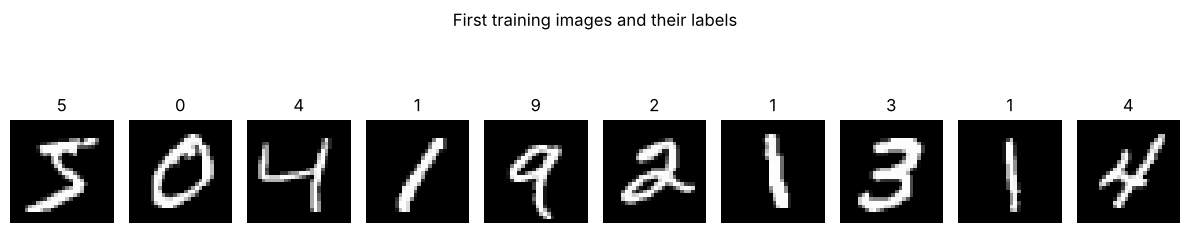

In [2]:
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.suptitle('First training images and their labels')
plt.tight_layout()
plt.show()

The dataset contains **60,000 training images** and **10,000 test images** of handwritten digits. Each image is a 28×28 grayscale array with values from 0 (black) to 255 (white), and each label is the digit (0–9).

## 2. Preprocess the data for a Fully Connected Neural Network

In [3]:
# Flatten 28x28 images into vectors of 784 pixels and normalise to [0, 1]
X_train_flat = X_train.reshape(X_train.shape[0], 28 * 28).astype("float32") / 255
X_test_flat = X_test.reshape(X_test.shape[0], 28 * 28).astype("float32") / 255

# One-hot encode the labels
# (keras.utils.np_utils.to_categorical in old Keras versions is now keras.utils.to_categorical)
y_train_oh = keras.utils.to_categorical(y_train, 10)
y_test_oh = keras.utils.to_categorical(y_test, 10)

print("X_train_flat:", X_train_flat.shape, "| X_test_flat:", X_test_flat.shape)
print("y_train_oh:", y_train_oh.shape, "| example:", y_train[0], "->", y_train_oh[0])

X_train_flat: (60000, 784) | X_test_flat: (10000, 784)
y_train_oh: (60000, 10) | example: 5 -> [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## 3. Build and train a Fully Connected Neural Network

In [4]:
keras.utils.set_random_seed(SEED)
fc_model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax'),
], name='fully_connected')

fc_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
fc_model.summary()

Model: "fully_connected"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
fc_history = fc_model.fit(X_train_flat, y_train_oh, epochs=10, batch_size=128, validation_split=0.1, verbose=2)

fc_loss, fc_acc = fc_model.evaluate(X_test_flat, y_test_oh, verbose=0)
print(f"\nFully connected network - test loss: {fc_loss:.4f} | test accuracy: {fc_acc:.4f}")

Epoch 1/10


422/422 - 4s - 10ms/step - accuracy: 0.9158 - loss: 0.2808 - val_accuracy: 0.9695 - val_loss: 0.0993


Epoch 2/10


422/422 - 2s - 5ms/step - accuracy: 0.9646 - loss: 0.1150 - val_accuracy: 0.9760 - val_loss: 0.0833


Epoch 3/10


...

Epoch 9/10


422/422 - 2s - 5ms/step - accuracy: 0.9914 - loss: 0.0260 - val_accuracy: 0.9807 - val_loss: 0.0787


Epoch 10/10


422/422 - 2s - 5ms/step - accuracy: 0.9918 - loss: 0.0249 - val_accuracy: 0.9793 - val_loss: 0.0901



Fully connected network - test loss: 0.0778 | test accuracy: 0.9798


## 4. Preprocess the data for a Convolutional Neural Network

In [6]:
# Conv2D expects (samples, height, width, channels): add a channel dimension (1 = grayscale)
X_train_cnn = X_train.reshape(X_train.shape[0], 28, 28, 1).astype("float32") / 255
X_test_cnn = X_test.reshape(X_test.shape[0], 28, 28, 1).astype("float32") / 255

# One-hot encoded labels (same as before)
y_train_oh = keras.utils.to_categorical(y_train, 10)
y_test_oh = keras.utils.to_categorical(y_test, 10)

print("X_train_cnn:", X_train_cnn.shape, "| X_test_cnn:", X_test_cnn.shape)

X_train_cnn: (60000, 28, 28, 1) | X_test_cnn: (10000, 28, 28, 1)


## 5. Build and train a Convolutional Neural Network

In [7]:
keras.utils.set_random_seed(SEED)
cnn_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),   # 28x28 -> 26x26x32
    layers.MaxPool2D(pool_size=(2, 2)),                          # -> 13x13x32
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),   # -> 11x11x64
    layers.MaxPool2D(pool_size=(2, 2)),                          # -> 5x5x64
    layers.Flatten(),                                            # -> 1600
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax'),
], name='cnn')

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()

Model: "cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
cnn_history = cnn_model.fit(X_train_cnn, y_train_oh, epochs=10, batch_size=128, validation_split=0.1, verbose=2)

cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test_oh, verbose=0)
print(f"\nCNN - test loss: {cnn_loss:.4f} | test accuracy: {cnn_acc:.4f}")

Epoch 1/10


422/422 - 7s - 16ms/step - accuracy: 0.9236 - loss: 0.2538 - val_accuracy: 0.9840 - val_loss: 0.0594


Epoch 2/10


422/422 - 6s - 13ms/step - accuracy: 0.9767 - loss: 0.0772 - val_accuracy: 0.9848 - val_loss: 0.0465


Epoch 3/10


...

Epoch 9/10


422/422 - 6s - 13ms/step - accuracy: 0.9939 - loss: 0.0194 - val_accuracy: 0.9903 - val_loss: 0.0414


Epoch 10/10


422/422 - 5s - 13ms/step - accuracy: 0.9946 - loss: 0.0169 - val_accuracy: 0.9905 - val_loss: 0.0428



CNN - test loss: 0.0261 | test accuracy: 0.9916


## 6. Compare the performance

In [9]:
fc_pred = fc_model.predict(X_test_flat, verbose=0).argmax(axis=1)
cnn_pred = cnn_model.predict(X_test_cnn, verbose=0).argmax(axis=1)

comparison = pd.DataFrame({
    'parameters': [fc_model.count_params(), cnn_model.count_params()],
    'test accuracy': [fc_acc, cnn_acc],
    'test loss': [fc_loss, cnn_loss],
    'misclassified test images': [(fc_pred != y_test).sum(), (cnn_pred != y_test).sum()],
    'best val accuracy': [max(fc_history.history['val_accuracy']), max(cnn_history.history['val_accuracy'])],
}, index=['Fully connected', 'CNN'])
display(comparison.style.format({'parameters': '{:,}', 'test accuracy': '{:.4f}', 'test loss': '{:.4f}', 'best val accuracy': '{:.4f}'}))

fc_err, cnn_err = (fc_pred != y_test).sum(), (cnn_pred != y_test).sum()
print(f"The CNN makes {fc_err - cnn_err} fewer errors ({(fc_err - cnn_err) / fc_err:.0%} fewer) with {cnn_model.count_params() / fc_model.count_params():.0%} of the parameters.")

,parameters,test accuracy,test loss,misclassified test images,best val accuracy
Fully connected,"535,818",0.9798,0.0778,202,0.9813
CNN,"225,034",0.9916,0.0261,84,0.9915


The CNN makes 118 fewer errors (58% fewer) with 42% of the parameters.


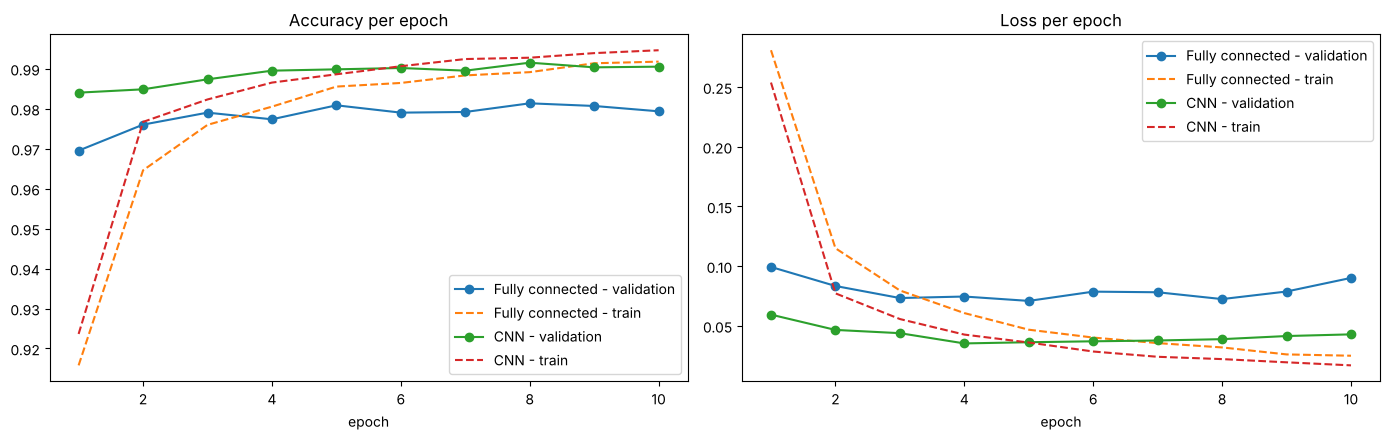

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for name, h in [('Fully connected', fc_history), ('CNN', cnn_history)]:
    epochs = range(1, len(h.history['loss']) + 1)
    axes[0].plot(epochs, h.history['val_accuracy'], 'o-', label=f'{name} - validation')
    axes[0].plot(epochs, h.history['accuracy'], '--', label=f'{name} - train')
    axes[1].plot(epochs, h.history['val_loss'], 'o-', label=f'{name} - validation')
    axes[1].plot(epochs, h.history['loss'], '--', label=f'{name} - train')
axes[0].set_title('Accuracy per epoch'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].set_title('Loss per epoch'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout()
plt.show()

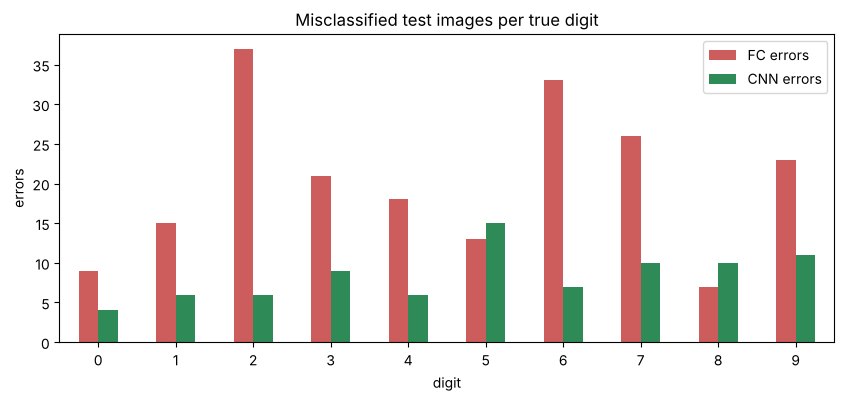

digit,0,1,2,3,4,5,6,7,8,9
FC errors,9,15,37,21,18,13,33,26,7,23
CNN errors,4,6,6,9,6,15,7,10,10,11


In [11]:
from sklearn.metrics import confusion_matrix

per_digit = pd.DataFrame({
    'FC errors': [((y_test == d) & (fc_pred != d)).sum() for d in range(10)],
    'CNN errors': [((y_test == d) & (cnn_pred != d)).sum() for d in range(10)],
}, index=range(10))
per_digit.index.name = 'digit'
per_digit.plot(kind='bar', figsize=(10, 4), rot=0, color=['indianred', 'seagreen'])
plt.title('Misclassified test images per true digit')
plt.ylabel('errors')
plt.show()
display(per_digit.T)

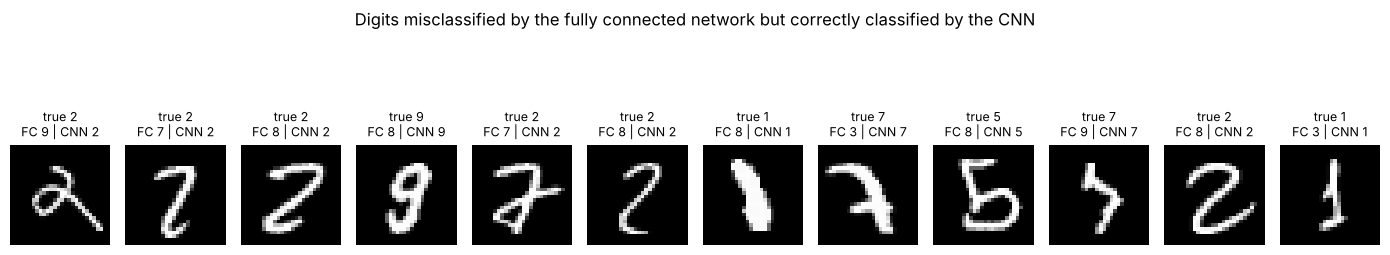

FC wrong & CNN right: 157 | CNN wrong & FC right: 39 | both wrong: 45


In [12]:
# Examples the fully connected network gets wrong but the CNN gets right
idx = np.where((fc_pred != y_test) & (cnn_pred == y_test))[0][:12]
plt.figure(figsize=(14, 3.5))
for i, k in enumerate(idx):
    plt.subplot(1, 12, i + 1)
    plt.imshow(X_test[k], cmap='gray')
    plt.title(f"true {y_test[k]}\nFC {fc_pred[k]} | CNN {cnn_pred[k]}", fontsize=9)
    plt.axis('off')
plt.suptitle('Digits misclassified by the fully connected network but correctly classified by the CNN')
plt.tight_layout()
plt.show()
print(f"FC wrong & CNN right: {((fc_pred != y_test) & (cnn_pred == y_test)).sum()} | "
      f"CNN wrong & FC right: {((cnn_pred != y_test) & (fc_pred == y_test)).sum()} | "
      f"both wrong: {((cnn_pred != y_test) & (fc_pred != y_test)).sum()}")

,Fully connected,CNN
shift (pixels right and down),,
0,0.9798,0.9916
2,0.5939,0.8535
3,0.2404,0.4676
4,0.0825,0.1401


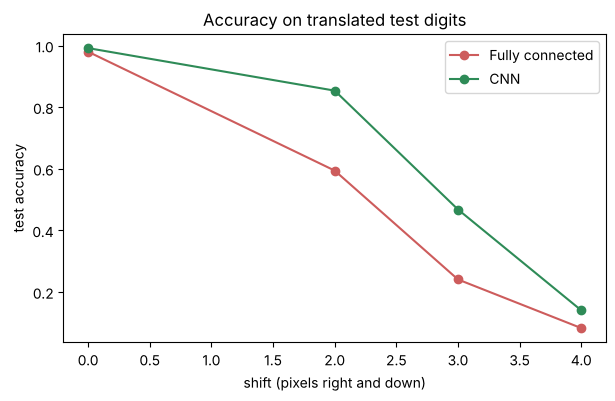

In [13]:
# Robustness to translation: shift every test digit by a few pixels and re-evaluate both models
def shift_images(X, dx, dy):
    return np.roll(np.roll(X, dy, axis=1), dx, axis=2)

rows = []
for shift in [0, 2, 3, 4]:
    Xs = shift_images(X_test, shift, shift).astype("float32") / 255
    acc_fc = (fc_model.predict(Xs.reshape(-1, 784), verbose=0).argmax(1) == y_test).mean()
    acc_cnn = (cnn_model.predict(Xs.reshape(-1, 28, 28, 1), verbose=0).argmax(1) == y_test).mean()
    rows.append({'shift (pixels right and down)': shift, 'Fully connected': acc_fc, 'CNN': acc_cnn})
shift_df = pd.DataFrame(rows).set_index('shift (pixels right and down)')
display(shift_df.style.format('{:.4f}'))

shift_df.plot(marker='o', figsize=(7, 4), color=['indianred', 'seagreen'])
plt.ylabel('test accuracy')
plt.title('Accuracy on translated test digits')
plt.show()

## Analysis of the results

| Model | Parameters | Test accuracy | Test loss | Misclassified test images |
|---|---|---|---|---|
| Fully connected (784 → 512 → 256 → 10) | 535,818 | 97.98% | 0.078 | 202 |
| **CNN** (2 × Conv2D + MaxPool2D, Dense 128) | **225,034** | **99.16%** | **0.026** | **84** |

**The CNN is clearly better:**
- **Accuracy:** 99.16% vs 97.98%. The difference looks small in percent, but the CNN makes **118 fewer errors, i.e. 58% fewer mistakes** (84 vs 202 out of 10,000).
- **Fewer parameters:** the CNN has 2.4 times fewer parameters (225k vs 536k) and still performs better. Convolution filters are small (3×3) and **shared** across the whole image, whereas each neuron of the first dense layer has its own weight for each of the 784 pixels.
- **Generalisation:** the fully connected network starts to **overfit** after about 5 epochs: its training loss keeps decreasing (to 0.025) while its validation loss goes back up (from 0.071 to 0.090). The CNN's validation loss stays much lower (0.035 at best, 0.043 at the end), so it generalises better.
- **Per digit:** the CNN reduces the errors on almost every digit, especially on the ones the dense network struggles with most: **2** (37 → 6 errors), **6** (33 → 7), **7** (26 → 10) and **9** (23 → 11). Out of the 202 errors of the dense network, the CNN fixes 157, while making only 39 new ones. The few digits both models get wrong are badly written or ambiguous even for a human.

**Why the CNN works better on images:**
- A fully connected network receives the image as a **flat list of 784 independent pixels**: flattening destroys the 2D structure, so the network does not know which pixels are neighbours and must learn every pattern separately for every position.
- A CNN keeps the **spatial structure**: its convolution filters detect **local patterns** (edges, curves, loops, line ends) wherever they appear in the image, and stacking layers combines them into more complex shapes (a loop on top of a vertical stroke = a 9). **MaxPooling** reduces the size of the feature maps and makes the detection more tolerant to small shifts and deformations.
- **Translation test:** when we move every test digit 2 pixels right and 2 pixels down, the dense network falls from 98.0% to **59.4%**, while the CNN still reaches **85.4%**. For larger shifts both models collapse (at 3–4 pixels, part of the digit leaves the centred region they were trained on and wraps around the image edge), but the CNN always stays ahead. Pooling only gives a *local* tolerance to shifts; data augmentation (random translations) would make it fully robust.

**Conclusion:** for image classification, the CNN is the better architecture. It is **more accurate, smaller and better at generalising**, because it exploits the spatial structure of the image instead of treating pixels as unrelated features. The fully connected network remains a good baseline on a simple, centred dataset like MNIST, but its limitations would be much more visible on real-world images (photos, objects at different positions and scales).